# Asignación de Operarios a Máquinas — ScheduleIt! Factory

Modelo de **programación lineal entera** (PuLP) para asignar 30 operarios a 10 máquinas distribuidas en 3 zonas de una planta industrial.

**Objetivo:** Maximizar las horas productivas de las zonas de Mezcla y Envasado, penalizando las capacitaciones necesarias.

**Zonas y máquinas:**
- **Abastecimiento** ($J_A$): A1, A2, A3
- **Mezcla** ($J_M$): M1, M2, M3
- **Envasado** ($J_E$): L1, L2, L3, L4

Los datos se consumen desde la API REST de `server.py`.

In [1]:
#!pip install requests pulp

In [2]:
import requests
import pandas as pd
from pulp import *
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

BASE_URL = "http://localhost:8000"
HEADERS = {"X-API-Key": "IO-TOKEN-GRP1-2025"}  # Cambiar según grupo

## Obtención de Datos desde la API

In [3]:
# Fetch todos los operarios (paginado)
operarios = []
page = 1
while True:
    r = requests.get(f"{BASE_URL}/operarios", headers=HEADERS, params={"page": page, "page_size": 10})
    r.raise_for_status()
    data = r.json()
    operarios.extend(data["data"])
    if page >= data["total_pages"]:
        break
    page += 1

print(f"Total operarios: {len(operarios)}")
df_op = pd.DataFrame(operarios)
df_op.head(10)

Total operarios: 30


,id,habilidades,grupo
0,1,"[M1, L3, L4]",3
1,2,"[M1, M2, L2, L4]",1
2,3,[M1],3
3,4,"[A, L1, L3]",1
4,5,"[M1, L4]",2
5,6,"[M3, L1, L2]",3
6,7,"[M2, L4]",2
7,8,"[M3, L3]",2
8,9,"[L3, L4]",1
9,10,"[M1, L1]",1


In [4]:
# Fetch procesos (no paginado) — confirmar duración capacitación = 8h
r = requests.get(f"{BASE_URL}/procesos", headers=HEADERS)
r.raise_for_status()
procesos = r.json()["procesos"]

for p in procesos:
    print(f"{p['codigo']:10s} | {p['nombre']:35s} | {p['duracion_hs']}h")

cap = next(p for p in procesos if p["codigo"] == "CAP")
DURACION_CAP = cap["duracion_hs"]
print(f"\nDuración capacitación: {DURACION_CAP}h")

LIMP       | Limpieza                            | 6h
CAP        | Capacitación                        | 8h
FMT_CIR    | Cambio de Formato a Círculo         | 4h
FMT_CUA    | Cambio de Formato a Cuadrado        | 6h

Duración capacitación: 8h


## Configuración de Partida

#### {Parametros}

Cada partida del juego se configura tirando dados:
- **1 dado** → grupo asignado a Mezcla (1-2→grupo 1, 3-4→grupo 2, 5-6→grupo 3)
- **2 dados** → la suma indica cuántos operarios están ausentes (se eligen al azar)

Los valores por defecto corresponden al ejemplo del PDF: grupo mezcla = 3, ausentes = {10, 14, 19, 21, 24}.

In [5]:
# ============================================================
# PARÁMETROS DE PARTIDA (modificar según tirada de dados)
# ============================================================
grupo_M = 2                        # Grupo asignado a Mezcla (1, 2 o 3)
ausentes = {28,29} #{10, 14}        # IDs de operarios ausentes
# ============================================================

print(f"Grupo asignado a Mezcla: {grupo_M}")
print(f"Operarios ausentes ({len(ausentes)}): {sorted(ausentes)}")

Grupo asignado a Mezcla: 2
Operarios ausentes (2): [28, 29]


## Conjuntos y Parámetros del Modelo

In [6]:
# Conjuntos de máquinas por zona
J_A = ["A1", "A2", "A3"]
J_M = ["M1", "M2", "M3"]
J_E = ["L1", "L2", "L3", "L4"]
J = J_A + J_M + J_E  # Todas las máquinas

# Conjunto de operarios (IDs)
I = [op["id"] for op in operarios]

# Dotación completa y mínima por máquina
q_full = {"A1": 1, "A2": 1, "A3": 1,
          "M1": 2, "M2": 2, "M3": 2,
          "L1": 7, "L2": 5, "L3": 3, "L4": 3}

q_min  = {"A1": 1, "A2": 1, "A3": 1,
          "M1": 1, "M2": 1, "M3": 1,
          "L1": 6, "L2": 4, "L3": 2, "L4": 2}

# Grupos de operarios
grupos_op = {op["id"]: op["grupo"] for op in operarios}

print("Máquinas:", J)
print("Operarios disponibles:", len([i for i in I if i not in ausentes]))
print("Operarios ausentes:", len(ausentes))

Máquinas: ['A1', 'A2', 'A3', 'M1', 'M2', 'M3', 'L1', 'L2', 'L3', 'L4']
Operarios disponibles: 28
Operarios ausentes: 2


![Distribución de máquinas](data/maquinas.png)

In [7]:
# Matriz de habilidades: hab[i][j] = 1 si operario i puede operar máquina j
# Mapping: "A" → A1,A2,A3; "M1"→M1; "L1"→L1; etc.

hab = {}
for op in operarios:
    i = op["id"]
    hab[i] = {}
    for j in J:
        hab[i][j] = 0
    for skill in op["habilidades"]:
        if skill == "A":
            for j in J_A:
                hab[i][j] = 1
        elif skill in J:
            hab[i][skill] = 1

# Verificar: mostrar cuántos operarios pueden operar cada máquina
for j in J:
    count = sum(hab[i][j] for i in I)
    print(f"  {j}: {count} operarios habilitados")

  A1: 9 operarios habilitados
  A2: 9 operarios habilitados
  A3: 9 operarios habilitados
  M1: 9 operarios habilitados
  M2: 10 operarios habilitados
  M3: 7 operarios habilitados
  L1: 9 operarios habilitados
  L2: 9 operarios habilitados
  L3: 13 operarios habilitados
  L4: 12 operarios habilitados


In [8]:
import pandas as pd

# Crear y mostrar matriz de habilidades como DataFrame
# Mostrar la matriz de habilidades como un DataFrame
df_hab = pd.DataFrame.from_dict(hab, orient='index')
df_hab.head(10)

,A1,A2,A3,M1,M2,M3,L1,L2,L3,L4
1,0,0,0,1,0,0,0,0,1,1
2,0,0,0,1,1,0,0,1,0,1
3,0,0,0,1,0,0,0,0,0,0
4,1,1,1,0,0,0,1,0,1,0
5,0,0,0,1,0,0,0,0,0,1
6,0,0,0,0,0,1,1,1,0,0
7,0,0,0,0,1,0,0,0,0,1
8,0,0,0,0,0,1,0,0,1,0
9,0,0,0,0,0,0,0,0,1,1
10,0,0,0,1,0,0,1,0,0,0


## Modelo PuLP

**Variables de decisión:**
- $x_{ij} \in \{0,1\}$: operario $i$ asignado a máquina $j$
- $y_j \in \{0,1\}$: máquina $j$ opera a dotación completa (40h)
- $y^{min}_j \in \{0,1\}$: máquina $j$ opera a dotación mínima (32h)
- $c_{ij} \in \{0,1\}$: operario $i$ se capacita para máquina $j$

**Función objetivo:**

$$\max \sum_{j \in J_M \cup J_E} \left(40 \cdot y_j + 32 \cdot y^{min}_j\right) - 8 \cdot \sum_{i \in I}\sum_{j \in J} c_{ij}$$

**Restricciones:**
1. Cada operario asignado a máximo 1 máquina
2. No más operarios que puestos ($\leq q^{full}_j$)
3. Ausentes no se asignan
4. Habilidad o capacitación ($x_{ij} \leq hab_{ij} + c_{ij}$)
5. Activación completa ($\sum_i x_{ij} \geq q^{full}_j \cdot y_j$)
6. Activación mínima ($\sum_i x_{ij} \geq q^{min}_j \cdot y^{min}_j$)
7. Exclusividad ($y_j + y^{min}_j \leq 1$)
8. Precedencia $y_{A1} = y_{M1} + y^{min}_{M1}$
9. Precedencia $y_{A2} = y_{M2} + y^{min}_{M2}$
10. Precedencia $y_{A3} = y_{M3} + y^{min}_{M3}$
11. Grupo mezcla no va a envasado
12. Otros grupos no van a mezcla ni abastecimiento
13. Máximo 1 capacitación

![Restricciones](data/restricciones.png)

#### Creamos el modelo y las vars de decisión

In [9]:
# Crear modelo
modelo = LpProblem("Asignacion_Operarios", LpMaximize)

# =======================
# Variables de decisión (binarias)
# =======================

# Operario i asignado a máquina j
x = LpVariable.dicts("x", [(i, j) for i in I for j in J], cat="Binary")

# Máquina j opera a dotación completa
y = LpVariable.dicts("y", J, cat="Binary")

# Máquina j opera a dotación mínima
y_min = LpVariable.dicts("y_min", J, cat="Binary")

# Operario i se capacita para
c = LpVariable.dicts("c", [(i, j) for i in I for j in J], cat="Binary")

In [10]:
# Función objetivo: max horas productivas (mezcla + envasado) - costo capacitaciones
J_prod = J_M + J_E  # Solo mezcla y envasado generan horas productivas

modelo += (
    lpSum(40 * y[j] + 32 * y_min[j] for j in J_prod)
    - DURACION_CAP * lpSum(c[i, j] for i in I for j in J),
    "FO_horas_productivas"
)

# ![Función objetivo](data/funcion_obj.png)

#### Restricciones

In [11]:
# R1: Cada operario (i en I) asignado a máximo 1 máquina (j en J)
for i in I:
    modelo += lpSum(x[i, j] for j in J) <= 1, f"R1_max1maq_{i}"

# R2: No más operarios que puestos (dotación completa como cota superior para cada máquina j en J)
for j in J:
    modelo += lpSum(x[i, j] for i in I) <= q_full[j], f"R2_capacidad_{j}"

# R3: Ausentes no se asignan (i en ausentes, j en J)
for i in ausentes:
    for j in J:
        modelo += x[i, j] == 0, f"R3_ausente_{i}_{j}"

# R4: Solo asignar si tiene habilidad o se capacita (operario i en I, máquina j en J)
for i in I:
    for j in J:
        modelo += x[i, j] <= hab[i][j] + c[i, j], f"R4_habilidad_{i}_{j}"

# R5: Activación completa — si y_j=1, necesita q_full operarios (máquina j en J)
for j in J:
    modelo += lpSum(x[i, j] for i in I) >= q_full[j] * y[j], f"R5_full_{j}"

# R6: Activación mínima — si y_min_j=1, necesita q_min operarios (máquina j en J)
for j in J:
    modelo += lpSum(x[i, j] for i in I) >= q_min[j] * y_min[j], f"R6_min_{j}"

# R7: Exclusividad — una máquina no puede estar full y min a la vez
for j in J:
    modelo += y[j] + y_min[j] <= 1, f"R7_exclusividad_{j}"

print(f"Restricciones R1-R7 agregadas")

Restricciones R1-R7 agregadas


In [12]:
# R8-R10: Precedencia — abastecimiento Ak activa si y solo si mezcla Mk opera
# y_Ak = y_Mk + y_min_Mk  (si Mk opera en cualquier modo, Ak debe estar activa full)
for k in range(3):
    ak = J_A[k]  # A1, A2, A3
    mk = J_M[k]  # M1, M2, M3
    modelo += y[ak] == y[mk] + y_min[mk], f"R{8+k}_precedencia_{ak}_{mk}"

# R11: Prohibición de asignación de operarios del grupo de Mezcla a Envasado.
# Para cada operario i, si pertenece al grupo de Mezcla (grupo_M),
# entonces no se le puede asignar a ninguna máquina de Envasado (todas en J_E).
for i in I:
    if grupos_op[i] == grupo_M:
        for j in J_E:
            # Restricción: los operarios de grupo Mezcla no pueden operar máquinas de Envasado.
            modelo += x[i, j] == 0, f"R11_grpM_no_env_{i}_{j}"

# R12: Prohibición de asignación de operarios de otros grupos a Mezcla o Abastecimiento.
# Para cada operario i, si NO pertenece al grupo de Mezcla (grupo_M),
# entonces no se le puede asignar ni a máquinas de Mezcla (J_M) ni de Abastecimiento (J_A).
for i in I:
    if grupos_op[i] != grupo_M:
        for j in J_M + J_A:
            # Restricción: operarios fuera del grupo Mezcla no pueden operar ni Mezcla ni Abastecimiento.
            modelo += x[i, j] == 0, f"R12_otros_no_mezcla_{i}_{j}"

# R13: Máximo 1 capacitación en TOTAL (no por operario)
modelo += lpSum(c[i, j] for i in I for j in J) <= 1, "R13_max1cap_total"

print(f"Restricciones R8-R13 agregadas")
print(f"Total restricciones: {modelo.numConstraints()}")
print(f"Total variables: {modelo.numVariables()}")

Restricciones R8-R13 agregadas
Total restricciones: 554
Total variables: 620


## Resolución

In [13]:
# Resolver
modelo.solve(PULP_CBC_CMD(msg=0))

print(f"Estado: {LpStatus[modelo.status]}")
print(f"Valor objetivo (horas productivas netas): {value(modelo.objective)}")

Estado: Optimal
Valor objetivo (horas productivas netas): 224.0


## Resultados

In [14]:
# Tabla de asignaciones
asignaciones = []
for i in I:
    for j in J:
        if value(x[i, j]) == 1:
            capacitado = value(c[i, j]) == 1
            zona = "Abastecimiento" if j in J_A else "Mezcla" if j in J_M else "Envasado"
            asignaciones.append({
                "Operario": i,
                "Grupo": grupos_op[i],
                "Máquina": j,
                "Zona": zona,
                "Capacitado": "Sí" if capacitado else "No"
            })

df_asig = pd.DataFrame(asignaciones).sort_values(["Zona", "Máquina", "Operario"])
print(f"Operarios asignados: {len(df_asig)}")
df_asig

Operarios asignados: 23


,Operario,Grupo,Máquina,Zona,Capacitado
13,17,2,A1,Abastecimiento,No
15,20,2,A3,Abastecimiento,Sí
2,4,1,L1,Envasado,No
3,6,3,L1,Envasado,No
6,10,1,L1,Envasado,No
7,11,1,L1,Envasado,No
8,12,3,L1,Envasado,No
14,19,3,L1,Envasado,No
1,2,1,L2,Envasado,No
9,13,3,L2,Envasado,No


In [15]:
# Estado de máquinas
print(f"{'Máquina':<10} {'Estado':<15} {'Operarios':<8} {'q_min':<6} {'q_full':<6} {'Horas'}")
print("-" * 60)
for j in J:
    n_ops = int(sum(value(x[i, j]) for i in I))
    if value(y[j]) == 1:
        estado = "FULL (40h)"
        horas = 40
    elif value(y_min[j]) == 1:
        estado = "MÍNIMA (32h)"
        horas = 32
    else:
        estado = "INACTIVA"
        horas = 0
    zona = "A" if j in J_A else "M" if j in J_M else "E"
    print(f"  {j:<8} {estado:<15} {n_ops:<8} {q_min[j]:<6} {q_full[j]:<6} {horas if j in J_prod else '-'}")

Máquina    Estado          Operarios q_min  q_full Horas
------------------------------------------------------------
  A1       FULL (40h)      1        1      1      -
  A2       INACTIVA        0        1      1      -
  A3       FULL (40h)      1        1      1      -
  M1       FULL (40h)      2        1      2      40
  M2       INACTIVA        0        1      2      0
  M3       FULL (40h)      2        1      2      40
  L1       MÍNIMA (32h)    6        6      7      32
  L2       FULL (40h)      5        4      5      40
  L3       FULL (40h)      3        2      3      40
  L4       FULL (40h)      3        2      3      40


In [16]:
# Desglose de horas productivas
horas_mezcla = sum(40 * value(y[j]) + 32 * value(y_min[j]) for j in J_M)
horas_envasado = sum(40 * value(y[j]) + 32 * value(y_min[j]) for j in J_E)
costo_cap = DURACION_CAP * sum(value(c[i, j]) for i in I for j in J)
n_cap = int(sum(value(c[i, j]) for i in I for j in J))

print(f"Horas productivas Mezcla:   {int(horas_mezcla)}h")
print(f"Horas productivas Envasado: {int(horas_envasado)}h")
print(f"Capacitaciones realizadas:  {n_cap} (costo: {int(costo_cap)}h)")
print(f"────────────────────────────────")
print(f"TOTAL NETO:                 {int(horas_mezcla + horas_envasado - costo_cap)}h")

Horas productivas Mezcla:   80h
Horas productivas Envasado: 152h
Capacitaciones realizadas:  1 (costo: 8h)
────────────────────────────────
TOTAL NETO:                 224h


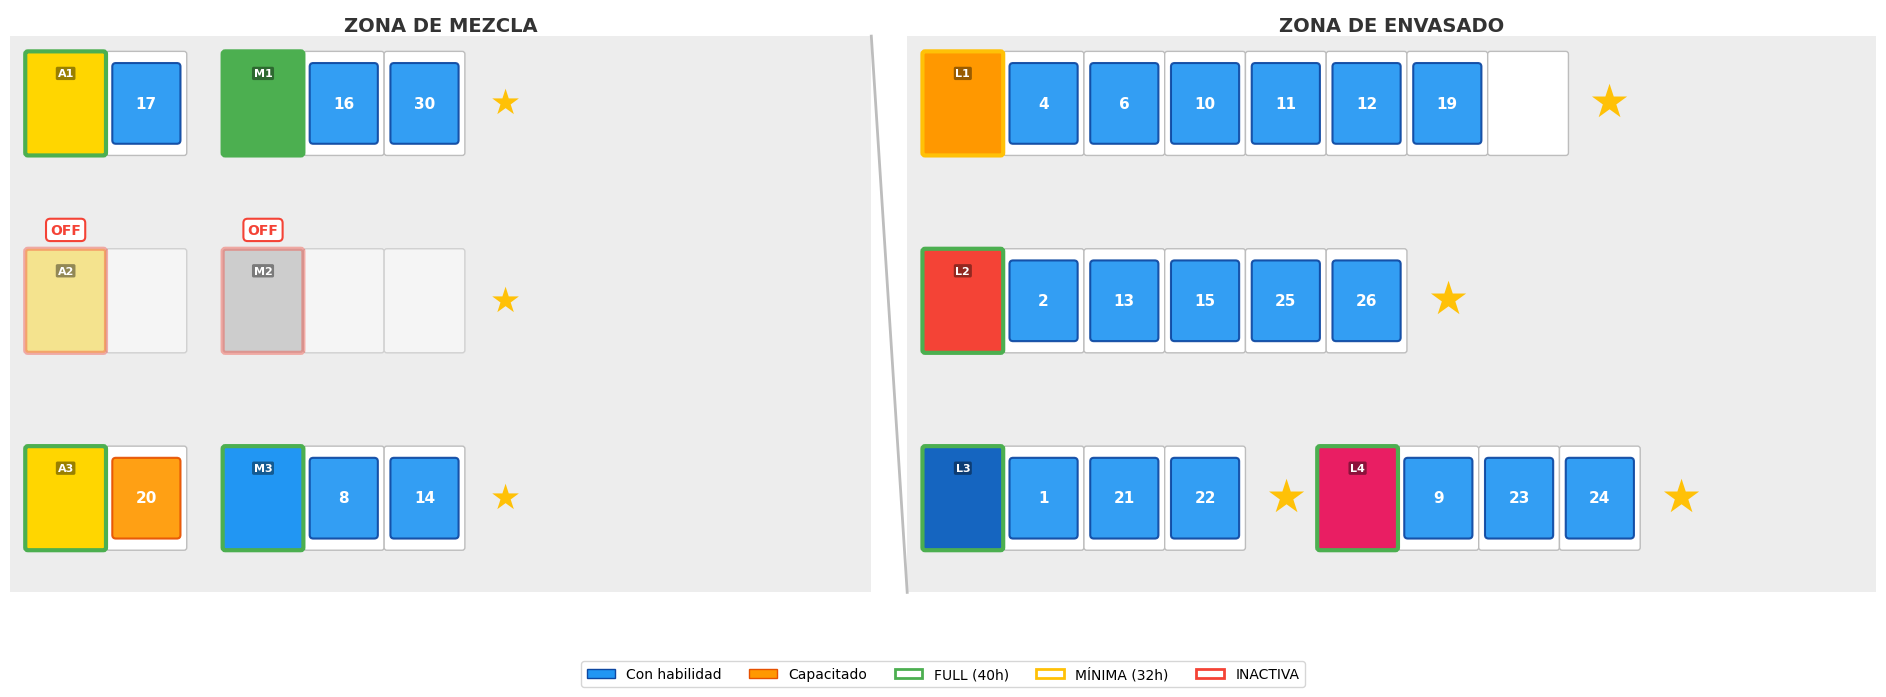

In [17]:
# Visualización de planta generada con matplotlib
from matplotlib.patches import FancyBboxPatch, Patch, Rectangle
                                                                                                                                                                                        
fig, ax = plt.subplots(figsize=(20, 7))                                                                                                                                                   
ax.set_xlim(0, 104)                                                                                                                                                                       
ax.set_ylim(-2, 34)                                                                                                                                                                       
ax.set_aspect('equal')                                                                                                                                                                    
ax.axis('off')
                                                                                                                                                                                        
MACH_COLORS = { 
    "A1": "#FFD600", "A2": "#FFD600", "A3": "#FFD600",
    "M1": "#4CAF50", "M2": "#9E9E9E", "M3": "#2196F3",                                                                                                                                    
    "L1": "#FF9800", "L2": "#F44336", "L3": "#1565C0", "L4": "#E91E63",                                                                                                                   
}                                                                                                                                                                                         
BADGE_SKILL = "#2196F3"                                                                                                                                                                   
BADGE_CAP   = "#FF9800"                                                                                                                                                                   
STATUS_FULL = "#4CAF50"                                                                                                                                                                   
STATUS_MIN  = "#FFC107"
STATUS_INACT = "#F44336"                                                                                                                                                                  
                
row_y = [26, 15, 4]                                                                                                                                                                       
box_w, box_h = 4.2, 5.5
gap = 0.3                                                                                                                                                                                 
                
ax.add_patch(Rectangle((0, 1.5), 48, 31, facecolor="#EDEDED", edgecolor="none", zorder=0))                                                                                                
ax.add_patch(Rectangle((50, 1.5), 54, 31, facecolor="#EDEDED", edgecolor="none", zorder=0))
ax.text(24, 32.8, "ZONA DE MEZCLA", ha='center', fontsize=14, fontweight='bold', color="#333")                                                                                            
ax.text(77, 32.8, "ZONA DE ENVASADO", ha='center', fontsize=14, fontweight='bold', color="#333")                                                                                          
                                                                                                                                                                                        
layout = [                                                                                                                                                                                
    ("A1", 0, 1),  ("M1", 0, 12),                                                                                                                                                         
    ("A2", 1, 1),  ("M2", 1, 12),                                                                                                                                                         
    ("A3", 2, 1),  ("M3", 2, 12),
    ("L1", 0, 51), ("L2", 1, 51),                                                                                                                                                         
    ("L3", 2, 51), ("L4", 2, 73),
]                                                                                                                                                                                         
                
machine_ops = {}                                                                                                                                                                          
for j in J:     
    machine_ops[j] = [(i, value(c[i, j]) == 1) for i in I if value(x[i, j]) == 1]                                                                                                         
                                                                                                                                                                                        
def get_status(j):                                                                                                                                                                        
    if value(y[j]) == 1:                                                                                                                                                                  
        return "full", STATUS_FULL                                                                                                                                                        
    elif value(y_min[j]) == 1:
        return "min", STATUS_MIN                                                                                                                                                          
    else:       
        return "off", STATUS_INACT

def draw_machine(ax, label, x0, y0, color, status_color, is_off=False):                                                                                                                   
    rect = FancyBboxPatch((x0, y0), box_w, box_h,
        boxstyle="round,pad=0.15", facecolor=color, edgecolor=status_color,                                                                                                               
        linewidth=3, zorder=2, alpha=0.4 if is_off else 1.0)                                                                                                                              
    ax.add_patch(rect)
    ax.text(x0 + box_w/2, y0 + box_h - 0.8, label,                                                                                                                                        
        ha='center', va='top', fontsize=8, fontweight='bold', color='white',
        bbox=dict(boxstyle='round,pad=0.15', facecolor='#00000066', edgecolor='none'),                                                                                                    
        zorder=3)                                                                                                                                                                         
    if is_off:                                                                                                                                                                            
        ax.text(x0 + box_w/2, y0 + box_h + 1.2, "OFF",                                                                                                                                    
            ha='center', va='center', fontsize=10, fontweight='bold', color=STATUS_INACT,                                                                                                 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=STATUS_INACT, linewidth=1.5),                                                                                
            zorder=5)                                                                                                                                                                     
                                                                                                                                                                                        
def draw_slot(ax, x0, y0, op_id=None, is_cap=False, dimmed=False):                                                                                                                        
    rect = FancyBboxPatch((x0, y0), box_w, box_h,
        boxstyle="round,pad=0.15", facecolor='#F5F5F5' if dimmed else 'white',                                                                                                            
        edgecolor='#D0D0D0' if dimmed else '#BDBDBD', linewidth=1, zorder=1)
    ax.add_patch(rect)                                                                                                                                                                    
    if op_id is not None:                                                                                                                                                                 
        color = BADGE_CAP if is_cap else BADGE_SKILL                                                                                                                                      
        edge = "#E65100" if is_cap else "#0D47A1"                                                                                                                                         
        badge = FancyBboxPatch((x0 + 0.4, y0 + 0.7), box_w - 0.8, box_h - 1.4,
            boxstyle="round,pad=0.2", facecolor=color, edgecolor=edge,                                                                                                                    
            linewidth=1.5, alpha=0.5 if dimmed else 0.92, zorder=3)
        ax.add_patch(badge)                                                                                                                                                               
        ax.text(x0 + box_w/2, y0 + box_h/2, str(op_id),
            ha='center', va='center', fontsize=11, fontweight='bold',                                                                                                                     
            color='white', alpha=0.5 if dimmed else 1.0, zorder=4)                                                                                                                        

def draw_star(ax, x0, y0, size=1.0):                                                                                                                                                      
    cx, cy = x0 + box_w/2, y0 + box_h/2
    ax.text(cx, cy, "★", ha='center', va='center',                                                                                                                                        
        fontsize=int(28 * size), color='#FFC107', zorder=2)
                                                                                                                                                                                        
for mach, row_idx, x_start in layout:                                                                                                                                                     
    yb = row_y[row_idx]
    n_full = q_full[mach]                                                                                                                                                                 
    ops = machine_ops[mach]
    status, sc = get_status(mach)
    is_off = (status == "off")
                                                                                                                                                                                        
    draw_machine(ax, mach, x_start, yb, MACH_COLORS[mach], sc, is_off=is_off)                                                                                                             
                                                                                                                                                                                        
    for slot_idx in range(n_full):                                                                                                                                                        
        sx = x_start + (slot_idx + 1) * (box_w + gap)
        if slot_idx < len(ops):                                                                                                                                                           
            op_id, is_cap = ops[slot_idx]
            draw_slot(ax, sx, yb, op_id, is_cap, dimmed=is_off)                                                                                                                           
        else:                                                                                                                                                                             
            draw_slot(ax, sx, yb, dimmed=is_off)
                                                                                                                                                                                        
    # Estrella solo para M y L (no para A)
    if mach not in J_A:                                                                                                                                                                   
        star_x = x_start + (n_full + 1) * (box_w + gap)                                                                                                                                   
        star_size = 1.2 if mach in J_E else 0.9                                                                                                                                           
        draw_star(ax, star_x, yb, star_size)                                                                                                                                              
                                                                                                                                                                                        
ax.plot([48, 50], [32.5, 1.5], color='#BDBDBD', linewidth=2, linestyle='-', zorder=1)                                                                                                     
                                                                                                                                                                                        
legend_elements = [                                                                                                                                                                       
    Patch(facecolor=BADGE_SKILL, edgecolor="#0D47A1", label="Con habilidad"),
    Patch(facecolor=BADGE_CAP, edgecolor="#E65100", label="Capacitado"),                                                                                                                  
    Patch(facecolor="none", edgecolor=STATUS_FULL, linewidth=2, label="FULL (40h)"),
    Patch(facecolor="none", edgecolor=STATUS_MIN, linewidth=2, label="MÍNIMA (32h)"),                                                                                                     
    Patch(facecolor="none", edgecolor=STATUS_INACT, linewidth=2, label="INACTIVA"),                                                                                                       
]                                                                                                                                                                                         
ax.legend(handles=legend_elements, loc="lower center", bbox_to_anchor=(0.5, -0.06),                                                                                                       
        ncol=5, fontsize=10, frameon=True)                                                                                                                                              
                                                                                                                                                                                        
plt.tight_layout()
plt.show()                                                                

In [18]:
df_asig

,Operario,Grupo,Máquina,Zona,Capacitado
13,17,2,A1,Abastecimiento,No
15,20,2,A3,Abastecimiento,Sí
2,4,1,L1,Envasado,No
3,6,3,L1,Envasado,No
6,10,1,L1,Envasado,No
7,11,1,L1,Envasado,No
8,12,3,L1,Envasado,No
14,19,3,L1,Envasado,No
1,2,1,L2,Envasado,No
9,13,3,L2,Envasado,No


In [19]:
# Estado de máquinas
print(f"{'Máquina':<10} {'Estado':<15} {'Operarios':<8} {'q_min':<6} {'q_full':<6} {'Horas'}")
print("-" * 60)
for j in J:
    n_ops = int(sum(value(x[i, j]) for i in I))
    if value(y[j]) == 1:
        estado = "FULL (40h)"
        horas = 40
    elif value(y_min[j]) == 1:
        estado = "MÍNIMA (32h)"
        horas = 32
    else:
        estado = "INACTIVA"
        horas = 0
    zona = "A" if j in J_A else "M" if j in J_M else "E"
    print(f"  {j:<8} {estado:<15} {n_ops:<8} {q_min[j]:<6} {q_full[j]:<6} {horas if j in J_prod else '-'}")

Máquina    Estado          Operarios q_min  q_full Horas
------------------------------------------------------------
  A1       FULL (40h)      1        1      1      -
  A2       INACTIVA        0        1      1      -
  A3       FULL (40h)      1        1      1      -
  M1       FULL (40h)      2        1      2      40
  M2       INACTIVA        0        1      2      0
  M3       FULL (40h)      2        1      2      40
  L1       MÍNIMA (32h)    6        6      7      32
  L2       FULL (40h)      5        4      5      40
  L3       FULL (40h)      3        2      3      40
  L4       FULL (40h)      3        2      3      40


## Scheduling de Operaciones

In [20]:
!pip install ortools

from ortools.sat.python import cp_model


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [21]:
# Fetch lotes de mezcla (22 lotes)
r = requests.get(f"{BASE_URL}/lotes/mezcla", headers=HEADERS, params={"page_size": 22})
r.raise_for_status()
lotes_mezcla = r.json()["data"]

# Fetch lotes de envasado (22 lotes)
r = requests.get(f"{BASE_URL}/lotes/envasado", headers=HEADERS, params={"page_size": 22})
r.raise_for_status()
lotes_envasado = r.json()["data"]

# Fetch entregas
r = requests.get(f"{BASE_URL}/entregas", headers=HEADERS)
r.raise_for_status()
entregas = {e["lote"]: e["dia_entrega"] for e in r.json()["entregas"]}

# Merge en lista unificada
lotes_data = []
for m, e in zip(lotes_mezcla, lotes_envasado):
    lotes_data.append({
        "lote": m["lote"],
        "hs_mezcla": m["hs"],
        "hs_envasado": e["hs"],
        "sabor": m["sabor"],
        "formato": e["formato"],
        "urgente": e["urgente"],
        "dia_entrega": entregas[m["lote"]],
    })

df_lotes = pd.DataFrame(lotes_data)
print(f"Total lotes: {len(lotes_data)}")
df_lotes

Total lotes: 22


,lote,hs_mezcla,hs_envasado,sabor,formato,urgente,dia_entrega
0,#101,4,7,3,cuadrado,True,martes
1,#102,4,7,2,circulo,False,miercoles
2,#103,4,6,1,cuadrado,True,lunes
3,#104,3,5,3,cuadrado,False,lunes
4,#105,4,6,3,cuadrado,False,miercoles
5,#106,4,6,2,cuadrado,False,martes
6,#107,3,5,1,cuadrado,False,miercoles
7,#108,3,5,2,cuadrado,False,miercoles
8,#109,3,5,3,cuadrado,True,lunes
9,#110,7,13,3,circulo,False,martes


In [22]:
# Máquinas activas (del modelo de asignación)
mezcladoras = [j for j in J_M if value(y[j]) == 1 or value(y_min[j]) == 1]
lineas = [j for j in J_E if value(y[j]) == 1 or value(y_min[j]) == 1]

# Capacidad horaria de cada máquina
cap_maq = {}
for j in mezcladoras + lineas:
    # pueden operar toda la semana si estan full o solo hasta el jueves si estan min
    cap_maq[j] = 40 if value(y[j]) == 1 else 32

# Asociación elevador → mezcladora
ELEV_A_MEZC = {"A1": "M1", "A2": "M2", "A3": "M3"}

# Disponibilidad inicial
start_disp = {}
for j in mezcladoras + lineas:
    has_cap = any(value(c[i, j]) == 1 for i in I)
    start_disp[j] = DURACION_CAP if has_cap else 0

# Si un elevador tiene capacitación, su mezcladora asociada también se demora
for ak in J_A:
    has_cap_elev = any(value(c[i, ak]) == 1 for i in I)
    if has_cap_elev:
        mk = ELEV_A_MEZC.get(ak)
        if mk and mk in mezcladoras:
            start_disp[mk] = max(start_disp[mk], DURACION_CAP)

# Deadlines por día de entrega
DEADLINE = {"lunes": 8, "martes": 16, "miercoles": 24, "jueves": 32}

# Formato inicial de líneas de envasado
FMT_INIT = {"L1": "cuadrado", "L2": "cuadrado", "L3": "circulo", "L4": "circulo"}

# Costos de setup (de la API /procesos)
T_LIMP = 6       # Limpieza por cambio de sabor descendente
T_FMT_CIR = 4    # Cambio a círculo (cuadrado → círculo)
T_FMT_CUA = 6    # Cambio a cuadrado (círculo → cuadrado)

print(f"Mezcladoras activas: {mezcladoras} → caps: {[cap_maq[m] for m in mezcladoras]}")
print(f"Líneas activas: {lineas} → caps: {[cap_maq[l] for l in lineas]}")
print(f"Start disponible: {start_disp}")

Mezcladoras activas: ['M1', 'M3'] → caps: [40, 40]
Líneas activas: ['L1', 'L2', 'L3', 'L4'] → caps: [32, 40, 40, 40]
Start disponible: {'M1': 0, 'M3': 8, 'L1': 0, 'L2': 0, 'L3': 0, 'L4': 0}


### Formulación CP-SAT

**Objetivo:** Maximizar la producción total ponderada (toneladas = 1 ton/h × hs_envasado; urgentes ×2)

**Variables:**
- `prod[l]` ∈ {0,1}: lote l se produce
- `start_m[l]`, `end_m[l]`: inicio/fin de mezcla del lote l
- `start_e[l]`, `end_e[l]`: inicio/fin de envasado del lote l
- `a_m[l, mk]`, `a_e[l, lk]` ∈ {0,1}: asignación a máquinas
- Arcos de circuito por máquina para secuenciación con setup times

**Restricciones:**
1. Asignación: cada lote producido → exactamente 1 mezcladora y 1 línea
2. Duración: end = start + hs
3. Precedencia: start_envasado ≥ end_mezcla
4. Deadline: end_envasado ≤ deadline del día de entrega
5. Capacidad: operaciones dentro del horizonte de la máquina (40h o 32h)
6. Secuenciación (`AddCircuit`): ordena lotes por máquina, garantiza no-overlap + setup times
7. Setup sabor: si sabor baja entre lotes consecutivos → +6h limpieza
8. Setup formato (envasado): cambio □→○ = +4h, ○→□ = +6h

In [23]:
mdl = cp_model.CpModel()

HORIZON = 40
N = len(lotes_data)
L = list(range(N))

# --- Variables ---

# Lote se produce
prod = {l: mdl.NewBoolVar(f"prod_{l}") for l in L}

# Tiempos de mezcla
start_m = {l: mdl.NewIntVar(0, HORIZON, f"sm_{l}") for l in L}
end_m   = {l: mdl.NewIntVar(0, HORIZON, f"em_{l}") for l in L}

# Tiempos de envasado
start_e = {l: mdl.NewIntVar(0, HORIZON, f"se_{l}") for l in L}
end_e   = {l: mdl.NewIntVar(0, HORIZON, f"ee_{l}") for l in L}

# Asignación a mezcladoras
a_m = {}
for l in L:
    for mk in mezcladoras:
        a_m[l, mk] = mdl.NewBoolVar(f"am_{l}_{mk}")

# Asignación a líneas de envasado
a_e = {}
for l in L:
    for lk in lineas:
        a_e[l, lk] = mdl.NewBoolVar(f"ae_{l}_{lk}")

print(f"Modelo creado: {N} lotes, {len(mezcladoras)} mezcladoras, {len(lineas)} líneas")

Modelo creado: 22 lotes, 2 mezcladoras, 4 líneas


In [24]:
# =============================================
# RESTRICCIONES
# =============================================

# --- R1: Asignación — lote producido va a exactamente 1 mezcladora y 1 línea ---
for l in L:
    mdl.Add(sum(a_m[l, mk] for mk in mezcladoras) == prod[l])
    mdl.Add(sum(a_e[l, lk] for lk in lineas) == prod[l])

# --- R2: Duración — end = start + hs ---
for l in L:
    mdl.Add(end_m[l] == start_m[l] + lotes_data[l]["hs_mezcla"]).OnlyEnforceIf(prod[l])
    mdl.Add(end_e[l] == start_e[l] + lotes_data[l]["hs_envasado"]).OnlyEnforceIf(prod[l])
    # Si no se produce, fijar a 0 (reduce dominio)
    mdl.Add(start_m[l] == 0).OnlyEnforceIf(prod[l].Not())
    mdl.Add(end_m[l] == 0).OnlyEnforceIf(prod[l].Not())
    mdl.Add(start_e[l] == 0).OnlyEnforceIf(prod[l].Not())
    mdl.Add(end_e[l] == 0).OnlyEnforceIf(prod[l].Not())

# --- R3: Precedencia — envasado empieza después de que termine mezcla ---
for l in L:
    mdl.Add(start_e[l] >= end_m[l]).OnlyEnforceIf(prod[l])

# --- R4: Deadline — envasado debe terminar antes del día de entrega ---
for l in L:
    dl = DEADLINE[lotes_data[l]["dia_entrega"]]
    #mdl.Add(end_e[l] <= dl).OnlyEnforceIf(prod[l])

# --- R5: Capacidad y disponibilidad por máquina ---
for l in L:
    for mk in mezcladoras:
        mdl.Add(end_m[l] <= cap_maq[mk]).OnlyEnforceIf(a_m[l, mk])
        mdl.Add(start_m[l] >= start_disp[mk]).OnlyEnforceIf(a_m[l, mk])
    for lk in lineas:
        mdl.Add(end_e[l] <= cap_maq[lk]).OnlyEnforceIf(a_e[l, lk])
        mdl.Add(start_e[l] >= start_disp[lk]).OnlyEnforceIf(a_e[l, lk])

# --- R6: Circuit mezcladoras (secuenciación + setup sabor) ---
for mk in mezcladoras:
    arcs = []
    arcs.append((0, 0, mdl.NewBoolVar(f"d0_m_{mk}")))  # dummy self-loop

    for l in L:
        n = l + 1
        # Self-loop: lote NO asignado a esta mezcladora
        arcs.append((n, n, a_m[l, mk].Not()))
        # Primer lote en la mezcladora
        arcs.append((0, n, mdl.NewBoolVar(f"first_m_{l}_{mk}")))
        # Último lote en la mezcladora
        arcs.append((n, 0, mdl.NewBoolVar(f"last_m_{l}_{mk}")))

    # Arcos entre pares de lotes (secuencia + setup sabor)
    for l1 in L:
        for l2 in L:
            if l1 == l2:
                continue
            lit = mdl.NewBoolVar(f"sq_m_{l1}_{l2}_{mk}")
            arcs.append((l1 + 1, l2 + 1, lit))
            # Setup: limpieza si sabor baja
            setup = T_LIMP if lotes_data[l1]["sabor"] > lotes_data[l2]["sabor"] else 0
            mdl.Add(start_m[l2] >= end_m[l1] + setup).OnlyEnforceIf(lit)

    mdl.AddCircuit(arcs)

# --- R7: Circuit líneas envasado (secuenciación + setup sabor + formato) ---
for lk in lineas:
    arcs = []
    arcs.append((0, 0, mdl.NewBoolVar(f"d0_e_{lk}")))
    fmt_init = FMT_INIT[lk]

    for l in L:
        n = l + 1
        # Self-loop: lote NO asignado a esta línea
        arcs.append((n, n, a_e[l, lk].Not()))

        # Primer lote: setup formato inicial
        first_lit = mdl.NewBoolVar(f"first_e_{l}_{lk}")
        arcs.append((0, n, first_lit))
        lot_fmt = lotes_data[l]["formato"]
        if fmt_init != lot_fmt:
            init_s = T_FMT_CIR if lot_fmt == "circulo" else T_FMT_CUA
        else:
            init_s = 0
        mdl.Add(start_e[l] >= start_disp[lk] + init_s).OnlyEnforceIf(first_lit)

        # Último lote
        arcs.append((n, 0, mdl.NewBoolVar(f"last_e_{l}_{lk}")))

    # Arcos entre pares (secuencia + setup sabor + formato)
    for l1 in L:
        for l2 in L:
            if l1 == l2:
                continue
            lit = mdl.NewBoolVar(f"sq_e_{l1}_{l2}_{lk}")
            arcs.append((l1 + 1, l2 + 1, lit))
            # Setup sabor
            s_flavor = T_LIMP if lotes_data[l1]["sabor"] > lotes_data[l2]["sabor"] else 0
            # Setup formato
            f1, f2 = lotes_data[l1]["formato"], lotes_data[l2]["formato"]
            s_fmt = 0
            if f1 != f2:
                s_fmt = T_FMT_CIR if f2 == "circulo" else T_FMT_CUA
            mdl.Add(start_e[l2] >= end_e[l1] + s_flavor + s_fmt).OnlyEnforceIf(lit)

    mdl.AddCircuit(arcs)

print("Restricciones agregadas")

Restricciones agregadas


#### Restriccion de comienzo-fin en mismo dia [off]

In [25]:
# # No-crossing: ninguna operación cruza una frontera de día
# BOUNDARIES = [8, 16, 24, 32]                                                                                                                                                    
                                                                                                                                                                                
# for l in L:                                                                                                                                                                     
#     for b in BOUNDARIES:                                                                                                                                                        
#         # Mezcla
#         bm = mdl.NewBoolVar(f"bm_{l}_{b}")                                                                                                                                      
#         mdl.Add(end_m[l] <= b).OnlyEnforceIf(bm)
#         mdl.Add(start_m[l] >= b).OnlyEnforceIf(bm.Not())                                                                                                                        
                
#         # Envasado                                                                                                                                                              
#         be = mdl.NewBoolVar(f"be_{l}_{b}")
#         mdl.Add(end_e[l] <= b).OnlyEnforceIf(be)                                                                                                                                
#         mdl.Add(start_e[l] >= b).OnlyEnforceIf(be.Not())

In [26]:
# =============================================
# FUNCIÓN OBJETIVO + RESOLVER
# =============================================

# Makespan (último envasado en terminar)
makespan = mdl.NewIntVar(0, HORIZON, "makespan")
for l in L:
    mdl.Add(makespan >= end_e[l]).OnlyEnforceIf(prod[l])

# Max producción ponderada (urgentes x2) - makespan como desempate
# El factor 1000 asegura que producir más siempre gana sobre reducir makespan
objective_terms = []
for l in L:
    peso = 2 if lotes_data[l]["urgente"] else 1
    toneladas = lotes_data[l]["hs_envasado"] * peso
    objective_terms.append(toneladas * prod[l])

mdl.Maximize(1000 * sum(objective_terms) - makespan)

# Resolver con timing
import time
solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 60 * 2

start_time = time.time()
status = solver.Solve(mdl)
end_time = time.time()
elapsed_time = end_time - start_time

print(f"Status: {solver.StatusName(status)}")
print(f"Tiempo de resolución: {elapsed_time:.2f} segundos")
if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
    print(f"Objetivo: {solver.ObjectiveValue()}")
    print(f"Makespan: {solver.Value(makespan)}h")
    print(f"Producción ponderada: {sum(solver.Value(t) for t in objective_terms)} ton")

Status: FEASIBLE
Tiempo de resolución: 120.08 segundos
Objetivo: 131960.0
Makespan: 40h
Producción ponderada: 132 ton


In [27]:
# Tabla de scheduling
resultados = []
for l in L:
    if solver.Value(prod[l]) == 0:
        continue
    maq_m = next(mk for mk in mezcladoras if solver.Value(a_m[l, mk]))
    maq_e = next(lk for lk in lineas if solver.Value(a_e[l, lk]))
    resultados.append({
        "Lote": lotes_data[l]["lote"],
        "Sabor": lotes_data[l]["sabor"],
        "Formato": lotes_data[l]["formato"],
        "Urgente": "Sí" if lotes_data[l]["urgente"] else "",
        "Mezcladora": maq_m,
        "Inicio M": solver.Value(start_m[l]),
        "Fin M": solver.Value(end_m[l]),
        "Línea": maq_e,
        "Inicio E": solver.Value(start_e[l]),
        "Fin E": solver.Value(end_e[l]),
        "Deadline": DEADLINE[lotes_data[l]["dia_entrega"]],
        "Entrega": lotes_data[l]["dia_entrega"],
    })

df_sched = pd.DataFrame(resultados).sort_values(["Mezcladora", "Inicio M"])
print(f"Lotes schedulados: {len(df_sched)}")
df_sched

Lotes schedulados: 16


,Lote,Sabor,Formato,Urgente,Mezcladora,Inicio M,Fin M,Línea,Inicio E,Fin E,Deadline,Entrega
14,#120,1,circulo,,M1,0,4,L4,4,11,32,jueves
15,#121,1,circulo,,M1,4,9,L1,9,19,8,lunes
2,#103,1,cuadrado,Sí,M1,9,13,L3,15,21,8,lunes
9,#112,2,circulo,,M1,13,16,L4,16,22,24,miercoles
13,#119,2,circulo,Sí,M1,16,21,L4,22,32,24,miercoles
6,#108,2,cuadrado,,M1,21,24,L3,24,29,24,miercoles
5,#106,2,cuadrado,,M1,24,28,L3,29,35,16,martes
1,#102,2,circulo,,M1,28,32,L4,32,39,24,miercoles
10,#114,1,cuadrado,,M3,8,10,L3,10,13,8,lunes
8,#111,3,cuadrado,,M3,10,14,L2,14,22,16,martes


In [37]:
# Resumen de producción
total_ton = 0
total_urgente = 0
por_linea = {lk: 0 for lk in lineas}

for l in L:
    if solver.Value(prod[l]) == 0:
        continue
    hs = lotes_data[l]["hs_envasado"]
    peso = 2 if lotes_data[l]["urgente"] else 1
    ton = hs * peso
    total_ton += ton
    if lotes_data[l]["urgente"]:
        total_urgente += ton
    lk = next(lk for lk in lineas if solver.Value(a_e[l, lk]))
    por_linea[lk] += hs

lotes_no_prod = [lotes_data[l]["lote"] for l in L if solver.Value(prod[l]) == 0]

print(f"{'='*45}")
print(f" RESUMEN DE PRODUCCIÓN")
print(f"{'='*45}")
print(f" Toneladas totales (ponderadas): {total_ton}")
print(f"   - Contribución urgentes:      {total_urgente}")
print(f" Lotes producidos: {sum(solver.Value(prod[l]) for l in L)} / {N}")
if lotes_no_prod:
    print(f" Lotes NO producidos: {lotes_no_prod}")
print(f"\n Horas de envasado por línea:")
for lk in lineas:
    print(f"   {lk}: {por_linea[lk]}h / {cap_maq[lk]}h ({por_linea[lk]/cap_maq[lk]*100:.0f}%)")

 RESUMEN DE PRODUCCIÓN
 Toneladas totales (ponderadas): 132
   - Contribución urgentes:      56
 Lotes producidos: 16 / 22
 Lotes NO producidos: ['#107', '#110', '#113', '#115', '#116', '#122']

 Horas de envasado por línea:
   L1: 23h / 32h (72%)
   L2: 26h / 40h (65%)
   L3: 25h / 40h (62%)
   L4: 30h / 40h (75%)


In [41]:
prod_total = sum(solver.Value(t) for t in objective_terms)
cant_operarios = len(df_asig)

def calcular_demoras(df):                                                     
    demoras = df[df["Fin E"] > df["Deadline"]].copy()                         
    demoras["Exceso"] = demoras["Fin E"] - demoras["Deadline"]                
    total = demoras["Exceso"].sum()                                           
    print(f"Lotes demorados: {len(demoras)} / {len(df)}")                     
    print(f"Horas totales de demora: {total}h")
    print(f"Dias totales de demora: {total/24} dias")
    return total/24

def calcular_demoras_no_prod(lotes_no_prod, lotes_data, DEADLINE):            
    resultados = []                                                           
    for l, lot in enumerate(lotes_data):                                    
        if lot["lote"] not in lotes_no_prod:
            continue
        deadline = DEADLINE[lot["dia_entrega"]]
        # Se produce la semana siguiente, entrega dummy = 40 + mezcla +envasado
        fin_dummy = 40 + lot["hs_mezcla"] + lot["hs_envasado"]
        exceso = fin_dummy - deadline
        resultados.append({
            "Lote": lot["lote"],
            "Entrega": lot["dia_entrega"],
            "Deadline": deadline,
            "Fin Dummy": fin_dummy,
            "Exceso (hs)": exceso
        })
    df = pd.DataFrame(resultados)
    total = df["Exceso (hs)"].sum()
    print(f"Lotes no producidos: {len(df)}")
    print(f"Horas totales de demora: {total}h")
    return total/24

def puntos(prod_total, cant_operarios, schedule, lotes_no_prod, lotes_data, DEADLINE):
    dias_demora_producidos = calcular_demoras(schedule)
    dias_demora_no_producidos = calcular_demoras_no_prod(lotes_no_prod, lotes_data, DEADLINE)
    return prod_total + (prod_total/cant_operarios) - dias_demora_producidos - dias_demora_no_producidos

print(f" Toneladas totales (ponderadas): {total_ton}")
print(f"   - Contribución urgentes:      {total_urgente}")
print(f" Lotes producidos: {sum(solver.Value(prod[l]) for l in L)} / {N}")
print(f"Puntaje: {puntos(prod_total, cant_operarios, df_sched, lotes_no_prod, lotes_data, DEADLINE)}")


 Toneladas totales (ponderadas): 132
   - Contribución urgentes:      56
 Lotes producidos: 16 / 22
Lotes demorados: 14 / 16
Horas totales de demora: 184h
Dias totales de demora: 7.666666666666667 dias
Lotes no producidos: 6
Horas totales de demora: 207h
Puntaje: 121.44746376811594


/Users/lucasargento/Downloads/Inpro/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


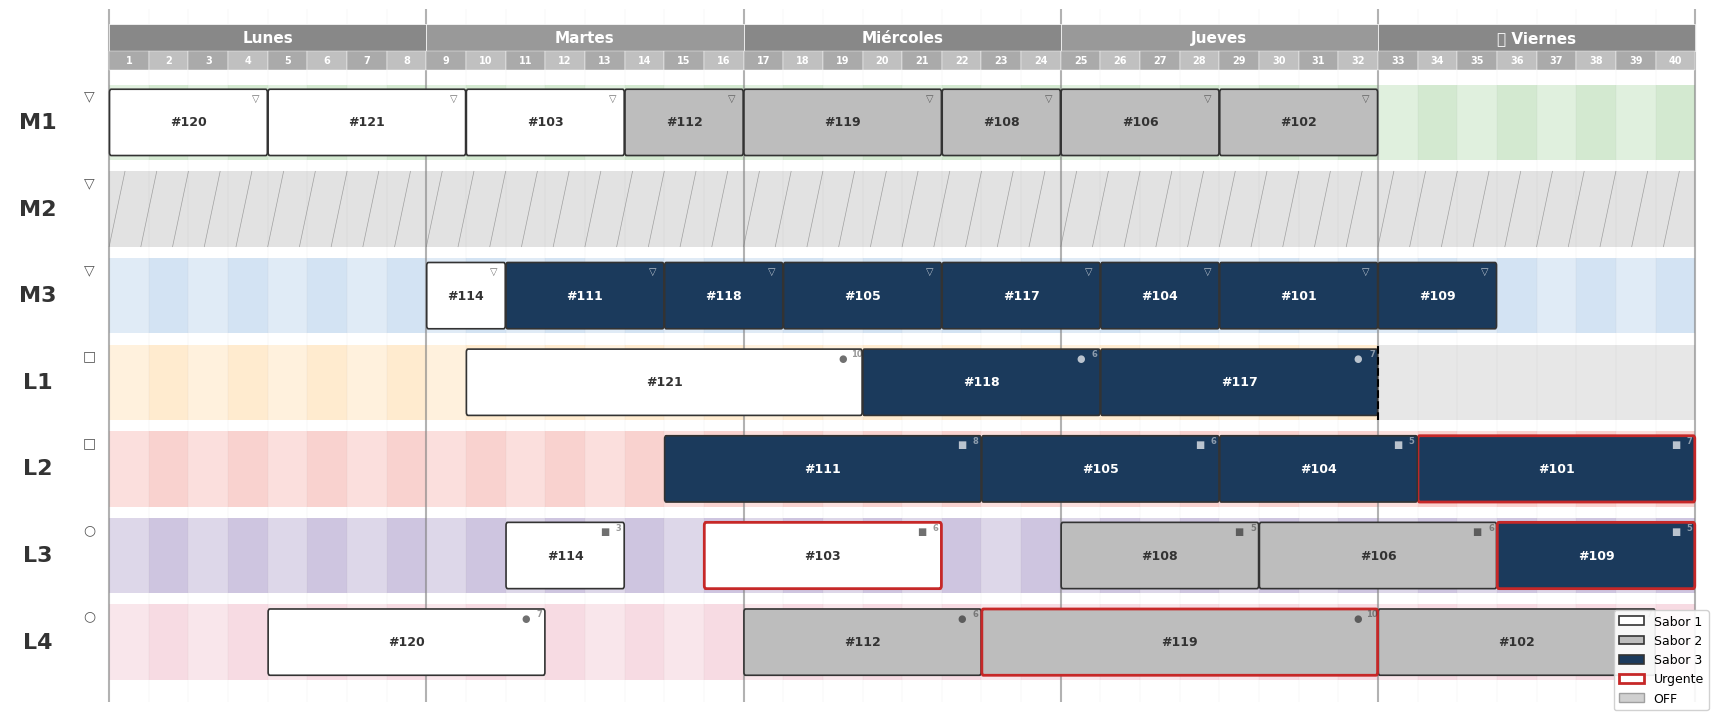

In [42]:
# Gantt Chart — Scheduling de Operaciones (estilo Planificador)                                                                                                                 
from matplotlib.patches import Patch, FancyBboxPatch, Rectangle                                                                                                                 
                                                                                                                                                                                
fig, ax = plt.subplots(figsize=(22, 9))                                                                                                                                         
                
# --- Configuración ---                                                                                                                                                         
ALL_MACHINES = J_M + J_E
ROW_H = 1.0                                                                                                                                                                     
GAP = 0.15                                                                                                                                                                      
TOTAL_ROWS = len(ALL_MACHINES)                                                                                                                                                  
                                                                                                                                                                                
BG_COLORS = {   
    "M1": "#A8D5A2", "M2": "#BDBDBD", "M3": "#A8C8E8",                                                                                                                          
    "L1": "#FFD9A0", "L2": "#F4A6A0", "L3": "#9E8DC2", "L4": "#F0B8C8",                                                                                                         
}                                                                                                                                                                               

LOTE_COLORS = {                                                    
      1: ("#FFFFFF", "#333333"),                                     
      2: ("#BDBDBD", "#333333"),                                     
      3: ("#1B3A5C", "#FFFFFF"),                                     
}                                                                                                                                                                              

MACHINE_ICONS = {
    "M1": u"\u25BD", "M2": u"\u25BD", "M3": u"\u25BD",                                                                                                                          
    "L1": u"\u25A1", "L2": u"\u25A1", "L3": u"\u25CB", "L4": u"\u25CB",                                                                                                         
}                                                                                                                                                                               
FMT_ICONS = {"cuadrado": u"\u25A0", "circulo": u"\u25CF"}  # filled versions                                                                                                    
                                                                                                                                                                                
y_map = {m: (TOTAL_ROWS - 1 - i) * (ROW_H + GAP) for i, m in enumerate(ALL_MACHINES)}                                                                                           
                                                                                                                                                                                
# --- Header: días y horas ---                                                                                                                                                  
header_y = TOTAL_ROWS * (ROW_H + GAP) + 0.05
day_h = 0.35                                                                                                                                                                    
hour_h = 0.25                                                                                                                                                                   
                                                                                                                                                                                
dias = ["Lunes", "Martes", u"Mi\u00e9rcoles", "Jueves", u"\u2B50 Viernes"]                                                                                                      
day_colors = ["#888888", "#999999", "#888888", "#999999", "#888888"]                                                                                                            
for i, (dia, dc) in enumerate(zip(dias, day_colors)):                                                                                                                           
    x0 = i * 8                                                                                                                                                                  
    ax.add_patch(Rectangle((x0, header_y + hour_h), 8, day_h,                                                                                                                   
                            facecolor=dc, edgecolor='white', linewidth=0.5, zorder=5))                                                                                          
    ax.text(x0 + 4, header_y + hour_h + day_h / 2, dia,                                                                                                                         
            ha='center', va='center', fontsize=11, fontweight='bold', color='white', zorder=6)                                                                                  
    for h in range(8):                                                                                                                                                          
        hx = x0 + h                                                                                                                                                             
        c = '#AAAAAA' if h % 2 == 0 else '#C0C0C0'                                                                                                                              
        ax.add_patch(Rectangle((hx, header_y), 1, hour_h,                                                                                                                       
                                facecolor=c, edgecolor='white', linewidth=0.3, zorder=5))                                                                                       
        ax.text(hx + 0.5, header_y + hour_h / 2, str(hx + 1),                                                                                                                   
                ha='center', va='center', fontsize=7, color='white', fontweight='bold', zorder=6)                                                                               
                                                                                                                                                                                
# --- Filas de máquinas ---                                                                                                                                                     
for m in ALL_MACHINES:                                                                                                                                                          
    yb = y_map[m]                                                                                                                                                               
    is_active = m in mezcladoras or m in lineas                                                                                                                                 
    bg = BG_COLORS[m]                                                                                                                                                           
                                                                                                                                                                                
    if is_active:                                                                                                                                                               
        cap = cap_maq[m]
        for h in range(int(cap)):                                                                                                                                               
            alpha = 0.35 if h % 2 == 0 else 0.50                                                                                                                                
            ax.add_patch(Rectangle((h, yb), 1, ROW_H,                                                                                                                           
                                    facecolor=bg, alpha=alpha, edgecolor='none', zorder=1))                                                                                     
        if cap < 40:
            ax.add_patch(Rectangle((cap, yb), 40 - cap, ROW_H,                                                                                                                  
                                    facecolor='#D0D0D0', alpha=0.5, edgecolor='none', zorder=1))                                                                                
            ax.plot([cap, cap], [yb, yb + ROW_H], color='black',                                                                                                                
                    linestyle='--', linewidth=1.5, zorder=4)                                                                                                                    
    else:                                                                                                                                                                       
        ax.add_patch(Rectangle((0, yb), 40, ROW_H,                                                                                                                              
                                facecolor='#D0D0D0', alpha=0.6, edgecolor='none', zorder=1))                                                                                    
        for stripe_x in np.arange(0, 40, 0.8):                                                                                                                                  
            ax.plot([stripe_x, stripe_x + 0.4], [yb, yb + ROW_H],                                                                                                               
                    color='#A0A0A0', linewidth=0.5, zorder=2)                                                                                                                   
                                                                                                                                                                                
    ax.text(-1.8, yb + ROW_H / 2, m, ha='center', va='center',                                                                                                                  
            fontsize=16, fontweight='bold', color='#333333', zorder=6)                                                                                                          
    ax.text(-0.5, yb + ROW_H - 0.15, MACHINE_ICONS[m], ha='center', va='center',                                                                                                
            fontsize=10, color='#555555', zorder=6)                                                                                                                             
                                                                                                                                                                                
# --- Barras de lotes ---                                                                                                                                                       
for l in L:     
    if solver.Value(prod[l]) == 0:                                                                                                                                              
        continue                                                                                                                                                                
    lote = lotes_data[l]["lote"]
    sabor = lotes_data[l]["sabor"]                                                                                                                                              
    formato = lotes_data[l]["formato"]
    urgente = lotes_data[l]["urgente"]                                                                                                                                          
    bg_color, txt_color = LOTE_COLORS[sabor]                                                                                                                                    
    bar_margin = 0.1
                                                                                                                                                                                
    # Barra mezcla
    mk = next(mk for mk in mezcladoras if solver.Value(a_m[l, mk]))                                                                                                             
    s, e = solver.Value(start_m[l]), solver.Value(end_m[l])                                                                                                                     
    yb = y_map[mk]                                                                                                                                                              
    rect = FancyBboxPatch((s + 0.05, yb + bar_margin), e - s - 0.1, ROW_H - 2 * bar_margin,                                                                                     
                            boxstyle="round,pad=0.04", facecolor=bg_color,                                                                                                       
                            edgecolor='#333333', linewidth=1.2, zorder=3)                                                                                                        
    ax.add_patch(rect)                                                                                                                                                          
    ax.text((s + e) / 2, yb + ROW_H / 2, lote,                                                                                                                                  
            ha='center', va='center', fontsize=9, fontweight='bold', color=txt_color, zorder=4)                                                                                 
    # Icono sabor (triángulo) en esquina superior derecha                                                                                                                       
    ax.text(e - 0.3, yb + ROW_H - 0.18, u"\u25BD",                                                                                                                              
            ha='center', va='center', fontsize=7, color=txt_color, alpha=0.7, zorder=4)                                                                                         
                                                                                                                                                                                
    # Barra envasado                                                                                                                                                            
    lk = next(lk for lk in lineas if solver.Value(a_e[l, lk]))                                                                                                                  
    s, e = solver.Value(start_e[l]), solver.Value(end_e[l])                                                                                                                     
    yb = y_map[lk]                                                                                                                                                              
    dur = e - s
    rect = FancyBboxPatch((s + 0.05, yb + bar_margin), e - s - 0.1, ROW_H - 2 * bar_margin,                                                                                     
                            boxstyle="round,pad=0.04", facecolor=bg_color,                                                                                                       
                            edgecolor='#333333', linewidth=1.2, zorder=3)                                                                                                        
    if urgente:                                                                                                                                                                 
        rect.set_edgecolor('#C62828')                                                                                                                                           
        rect.set_linewidth(2.0)                                                                                                                                                 
    ax.add_patch(rect)                                                                                                                                                          
    ax.text((s + e) / 2, yb + ROW_H / 2, lote,
            ha='center', va='center', fontsize=9, fontweight='bold', color=txt_color, zorder=4)                                                                                 
    # Icono formato (□ o ●) en esquina superior derecha                                                                                                                         
    fmt_icon = FMT_ICONS[formato]                                                                                                                                               
    ax.text(e - 0.5, yb + ROW_H - 0.18, fmt_icon,                                                                                                                               
            ha='center', va='center', fontsize=7, color=txt_color, alpha=0.7, zorder=4)                                                                                         
    # Duración como superíndice al lado del icono                                                                                                                               
    ax.text(e - 0.15, yb + ROW_H - 0.13, str(dur),                                                                                                                              
            ha='center', va='center', fontsize=6, fontweight='bold', color=txt_color, alpha=0.5, zorder=4)                                                                      
                                                                                                                                                                                
# --- Grid ---                                                                                                                                                                  
for h in range(41):
    lw = 1.5 if h % 8 == 0 else 0.3                                                                                                                                             
    al = 0.6 if h % 8 == 0 else 0.15                                                                                                                                            
    ax.axvline(x=h, color='gray', linewidth=lw, alpha=al, zorder=2)                                                                                                             
                                                                                                                                                                                
# --- Decoración ---                                                                                                                                                            
ax.set_xlim(-2.5, 40.5)                                                                                                                                                         
ax.set_ylim(-0.3, header_y + day_h + hour_h + 0.2)                                                                                                                              
ax.set_xticks([])                                                                                                                                                               
ax.set_yticks([])                                                                                                                                                               
ax.axis('off')                                                                                                                                                                  
                
legend_items = [                                                   
      Patch(facecolor='#FFFFFF', edgecolor='#333333', linewidth=1.2, 
  label='Sabor 1'),                                                  
      Patch(facecolor='#BDBDBD', edgecolor='#333333', linewidth=1.2, 
  label='Sabor 2'),                                                  
      Patch(facecolor='#1B3A5C', edgecolor='#333333', linewidth=1.2, 
  label='Sabor 3'),                                                  
      Patch(facecolor='white', edgecolor='#C62828', linewidth=2.0,   
  label='Urgente'),                                                  
      Patch(facecolor='#D0D0D0', edgecolor='#A0A0A0', label='OFF'),  
  ]                                                                                                                                                                                         
ax.legend(handles=legend_items, loc='lower right', fontsize=9, framealpha=0.9,                                                                                                  
        bbox_to_anchor=(1.0, -0.02))                                                                                                                                          
                                                                                                                                                                                
fig.subplots_adjust(top=0.88)                                                                                                                                                   
plt.show()                      

In [43]:
prod_total = sum(solver.Value(t) for t in objective_terms)
cant_operarios = len(df_asig)

def calcular_demoras(df):                                                     
    demoras = df[df["Fin E"] > df["Deadline"]].copy()                         
    demoras["Exceso"] = demoras["Fin E"] - demoras["Deadline"]                
    total = demoras["Exceso"].sum()                                           
    print(f"Lotes demorados: {len(demoras)} / {len(df)}")                     
    print(f"Horas totales de demora: {total}h")
    print(f"Dias totales de demora: {total/24} dias")
    return total/24

def calcular_demoras_no_prod(lotes_no_prod, lotes_data, DEADLINE):            
    resultados = []                                                           
    for l, lot in enumerate(lotes_data):                                    
        if lot["lote"] not in lotes_no_prod:
            continue
        deadline = DEADLINE[lot["dia_entrega"]]
        # Se produce la semana siguiente, entrega dummy = 40 + mezcla +envasado
        fin_dummy = 40 + lot["hs_mezcla"] + lot["hs_envasado"]
        exceso = fin_dummy - deadline
        resultados.append({
            "Lote": lot["lote"],
            "Entrega": lot["dia_entrega"],
            "Deadline": deadline,
            "Fin Dummy": fin_dummy,
            "Exceso (hs)": exceso
        })
    df = pd.DataFrame(resultados)
    total = df["Exceso (hs)"].sum()
    print(f"Lotes no producidos: {len(df)}")
    print(f"Horas totales de demora: {total}h")
    return total/24

def puntos(prod_total, cant_operarios, schedule, lotes_no_prod, lotes_data, DEADLINE):
    dias_demora_producidos = calcular_demoras(schedule)
    dias_demora_no_producidos = calcular_demoras_no_prod(lotes_no_prod, lotes_data, DEADLINE)
    return prod_total + (prod_total/cant_operarios) - dias_demora_producidos - dias_demora_no_producidos

print(f" Toneladas totales (ponderadas): {total_ton}")
print(f"   - Contribución urgentes:      {total_urgente}")
print(f" Lotes producidos: {sum(solver.Value(prod[l]) for l in L)} / {N}")
print(f"Puntaje: {puntos(prod_total, cant_operarios, df_sched, lotes_no_prod, lotes_data, DEADLINE)}")


 Toneladas totales (ponderadas): 132
   - Contribución urgentes:      56
 Lotes producidos: 16 / 22
Lotes demorados: 14 / 16
Horas totales de demora: 184h
Dias totales de demora: 7.666666666666667 dias
Lotes no producidos: 6
Horas totales de demora: 207h
Puntaje: 121.44746376811594
